# Tensor-RL Experiments
Demonstration notebook for all training scenarios. Most cells print the CLI command to run rather than executing a full sweep (training takes minutes–hours). The final section shows how to load saved results and run analysis.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

def run_name(env, algo, network, rank, tensorize_layers='all', seed=42, structured=False):
    if structured:
        return f'{env}_{algo}_{network}_rank{rank}_struct_seed{seed}'
    tz = f'_tz{tensorize_layers.replace(",","-")}' if tensorize_layers != 'all' else ''
    return f'{env}_{algo}_{network}_rank{rank}{tz}_seed{seed}'

ENV = 'MiniGrid-Empty-5x5-v0'
print('Setup complete.')

Setup complete.


## 1. Standard DQN Variants
Three algorithms, each using standard (non-tensorized) linear layers.

In [2]:
algos = ['dqn', 'double_dqn', 'dueling_dqn']
for algo in algos:
    cmd = f'conda run -n tensor python train.py --env {ENV} --algo {algo} --network standard --episodes 500'
    print(cmd)

conda run -n tensor python train.py --env MiniGrid-Empty-5x5-v0 --algo dqn --network standard --episodes 500
conda run -n tensor python train.py --env MiniGrid-Empty-5x5-v0 --algo double_dqn --network standard --episodes 500
conda run -n tensor python train.py --env MiniGrid-Empty-5x5-v0 --algo dueling_dqn --network standard --episodes 500


## 2. Tensor Decomposition Sweep
Grid over network types and ranks using Double DQN.

In [3]:
networks = ['standard', 'cp', 'tucker', 'tt']
ranks = [2, 4, 8]
for net in networks:
    for rank in ranks:
        if net == 'standard' and rank != ranks[0]:
            continue  # standard ignores rank
        cmd = (f'conda run -n tensor python train.py '
               f'--algo double_dqn --network {net} --rank {rank} --episodes 500')
        print(cmd)

conda run -n tensor python train.py --algo double_dqn --network standard --rank 2 --episodes 500
conda run -n tensor python train.py --algo double_dqn --network cp --rank 2 --episodes 500
conda run -n tensor python train.py --algo double_dqn --network cp --rank 4 --episodes 500
conda run -n tensor python train.py --algo double_dqn --network cp --rank 8 --episodes 500
conda run -n tensor python train.py --algo double_dqn --network tucker --rank 2 --episodes 500
conda run -n tensor python train.py --algo double_dqn --network tucker --rank 4 --episodes 500
conda run -n tensor python train.py --algo double_dqn --network tucker --rank 8 --episodes 500
conda run -n tensor python train.py --algo double_dqn --network tt --rank 2 --episodes 500
conda run -n tensor python train.py --algo double_dqn --network tt --rank 4 --episodes 500
conda run -n tensor python train.py --algo double_dqn --network tt --rank 8 --episodes 500


## 3. Selective Layer Tensorization
Use `--tensorize_layers` to choose which layers are decomposed.
Indices: 0=first hidden, 1=second hidden, 2=output (for 2 hidden layers).

In [4]:
# Compare full decomposition vs first-layer-only vs output-layer-only
configs = [
    ('all',  'all layers tensorized'),
    ('0',    'first hidden layer only'),
    ('1',    'second hidden layer only'),
    ('0,2',  'first hidden + output layer'),
    ('none', 'no decomposition (standard baseline)'),
]
for tz, desc in configs:
    cmd = (f'conda run -n tensor python train.py '
           f'--algo double_dqn --network cp --rank 4 '
           f'--tensorize_layers {tz} --episodes 500  # {desc}')
    print(cmd)

conda run -n tensor python train.py --algo double_dqn --network cp --rank 4 --tensorize_layers all --episodes 500  # all layers tensorized
conda run -n tensor python train.py --algo double_dqn --network cp --rank 4 --tensorize_layers 0 --episodes 500  # first hidden layer only
conda run -n tensor python train.py --algo double_dqn --network cp --rank 4 --tensorize_layers 1 --episodes 500  # second hidden layer only
conda run -n tensor python train.py --algo double_dqn --network cp --rank 4 --tensorize_layers 0,2 --episodes 500  # first hidden + output layer
conda run -n tensor python train.py --algo double_dqn --network cp --rank 4 --tensorize_layers none --episodes 500  # no decomposition (standard baseline)


## 4. Tabular Agents Demo
Run `TabularQAgent`, `SarsaAgent`, and `TensorizedTabularQAgent` directly on FrozenLake-v1 (discrete state space). This runs inline — no CLI needed.

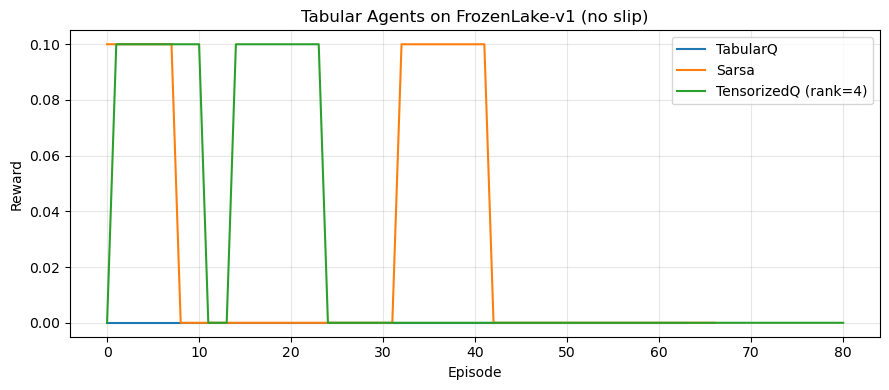

In [5]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from agents.tabular_q import TabularQAgent, SarsaAgent, TensorizedTabularQAgent

def run_tabular(agent, env_id='FrozenLake-v1', n_steps=2000, seed=42):
    env = gym.make(env_id, is_slippery=False)
    state, _ = env.reset(seed=seed)
    ep_reward = 0.0
    ep_rewards = []
    for _ in range(n_steps):
        action = agent.select_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        agent.update(state, action, reward, next_state, done)
        ep_reward += reward
        if done:
            ep_rewards.append(ep_reward)
            ep_reward = 0.0
            state, _ = env.reset()
        else:
            state = next_state
    return ep_rewards

S, A = 16, 4  # FrozenLake 4x4
agents = {
    'TabularQ': TabularQAgent(S, A, epsilon_decay_steps=1000),
    'Sarsa': SarsaAgent(S, A, epsilon_decay_steps=1000),
    'TensorizedQ (rank=4)': TensorizedTabularQAgent(S, A, rank=4, epsilon_decay_steps=1000),
}

plt.figure(figsize=(9, 4))
for name, agent in agents.items():
    ep_rewards = run_tabular(agent, n_steps=2000)
    window = 10
    smoothed = np.convolve(ep_rewards, np.ones(window)/window, mode='valid') if len(ep_rewards) >= window else ep_rewards
    plt.plot(smoothed, label=name)
plt.xlabel('Episode'); plt.ylabel('Reward'); plt.title('Tabular Agents on FrozenLake-v1 (no slip)')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 5. Multi-Seed Run
Use `--seeds` to run the same config with multiple seeds and produce an aggregate JSON.

In [6]:
cmd = ('conda run -n tensor python train.py '
       '--algo double_dqn --network cp --rank 4 --seeds 42,43,44 --episodes 500')
print(cmd)
# Produces:
#   sim/data/..._seed42.json
#   sim/data/..._seed43.json
#   sim/data/..._seed44.json
#   sim/data/..._agg.json   ← mean/std across seeds

conda run -n tensor python train.py --algo double_dqn --network cp --rank 4 --seeds 42,43,44 --episodes 500


## 6. Structured (Non-Flattened) TN Input

### Motivation

The flat pipeline (`make_env` → `FlattenObservation`) collapses the MiniGrid observation from shape `(7, 7, 3)` — representing *grid-x × grid-y × channel* — into a 1D vector of length 147. Once flattened, all three tensor layer types (CP, Tucker, TT) receive a 2D matrix and operate on a 2D weight matrix. For a 2D matrix, CP/Tucker/TT all reduce to low-rank matrix factorisation — mathematically equivalent to truncated SVD of a plain `nn.Linear`. **There is nothing genuinely tensor-structured happening.**

The structured path preserves the `(7, 7, 3)` shape and uses `TTEmbedding` or `CPEmbedding` as the first network layer. These layers contract a separate core (TT) or factor matrix (CP) over each of the three spatial modes independently, exploiting the independence structure of the *x-position*, *y-position*, and *channel* axes. This is the correct tensor-network function approximation claim: each mode is a separate tensor index, not part of an undifferentiated flat vector.

Architecture with `--structured`:
```
(batch, 7, 7, 3)
  → TTEmbedding / CPEmbedding   → (batch, 128)   [genuine TN layer]
  → ReLU
  → Linear(128, 128)             → (batch, 128)   [standard hidden]
  → ReLU
  → Linear(128, action_dim)      → (batch, 7)     [output head]
```

In [7]:
# CLI commands to compare structured TN vs flat baseline
cmds = [
    f'conda run -n tensor python train.py --env {ENV} --algo dqn --network tt --structured --rank 4 --episodes 500',
    f'conda run -n tensor python train.py --env {ENV} --algo dqn --network cp --structured --rank 4 --episodes 500',
    f'conda run -n tensor python train.py --env {ENV} --algo dqn --network standard --episodes 500  # flat baseline',
]
for cmd in cmds:
    print(cmd)

conda run -n tensor python train.py --env MiniGrid-Empty-5x5-v0 --algo dqn --network tt --structured --rank 4 --episodes 500
conda run -n tensor python train.py --env MiniGrid-Empty-5x5-v0 --algo dqn --network cp --structured --rank 4 --episodes 500
conda run -n tensor python train.py --env MiniGrid-Empty-5x5-v0 --algo dqn --network standard --episodes 500  # flat baseline


In [8]:
# Demonstrate parameter compression without running training
import torch.nn as nn
from models.tensor_layers import TTEmbedding, CPEmbedding

mode_dims = (7, 7, 3)   # MiniGrid-Empty-5x5-v0 observation shape
out_features = 128
rank = 4

flat_linear = nn.Linear(7 * 7 * 3, out_features)  # standard flat baseline
tt_emb = TTEmbedding(mode_dims=mode_dims, out_features=out_features, rank=rank)
cp_emb = CPEmbedding(mode_dims=mode_dims, out_features=out_features, rank=rank)

flat_params = sum(p.numel() for p in flat_linear.parameters())

print(f'nn.Linear(147, 128)  : {flat_params:>6} params  (baseline)')
print(f'TTEmbedding  rank={rank} : {tt_emb.parameter_count:>6} params  ({flat_params/tt_emb.parameter_count:.1f}x compression)')
print(f'CPEmbedding  rank={rank} : {cp_emb.parameter_count:>6} params  ({flat_params/cp_emb.parameter_count:.1f}x compression)')

# Verify forward pass shapes
import torch
x = torch.randn(4, 7, 7, 3)  # batch of 4 MiniGrid observations
print(f'\nTTEmbedding output shape: {tt_emb(x).shape}')  # expect (4, 128)
print(f'CPEmbedding output shape: {cp_emb(x).shape}')   # expect (4, 128)

nn.Linear(147, 128)  :  18944 params  (baseline)
TTEmbedding  rank=4 :   1804 params  (10.5x compression)
CPEmbedding  rank=4 :    708 params  (26.8x compression)

TTEmbedding output shape: torch.Size([4, 128])
CPEmbedding output shape: torch.Size([4, 128])


## 7. Load and Analyse Results
After running training, use `analysis/stats.py` to inspect and compare runs.

In [9]:
from analysis.stats import load_data, plot_learning_curves, plot_param_efficiency, plot_stability, run_statistical_tests

runs, agg_runs = load_data('sim/data')
print(f'Loaded {len(runs)} run(s) and {len(agg_runs)} aggregate file(s).')
for r in runs:
    print(f"  {r['name']}  —  {len(r['metrics'].get('rewards', []))} episodes")

Loaded 10 run(s) and 0 aggregate file(s).
  FrozenLake-v1_sarsa_cp_rank4_seed42  —  1000 episodes
  FrozenLake-v1_sarsa_seed42  —  1000 episodes
  FrozenLake-v1_sarsa_tt_rank4_seed42  —  1000 episodes
  FrozenLake-v1_sarsa_tucker_rank4_seed42  —  1000 episodes
  FrozenLake-v1_tabular_q_cp_rank4_seed42  —  1000 episodes
  FrozenLake-v1_tabular_q_seed42  —  1000 episodes
  FrozenLake-v1_tabular_q_tt_rank4_seed42  —  1000 episodes
  FrozenLake-v1_tabular_q_tucker_rank4_seed42  —  1000 episodes
  MiniGrid-Empty-5x5-v0_dqn_cp_rank4_seed42  —  100 episodes
  MiniGrid-Empty-5x5-v0_dqn_standard_rank4_seed42  —  100 episodes


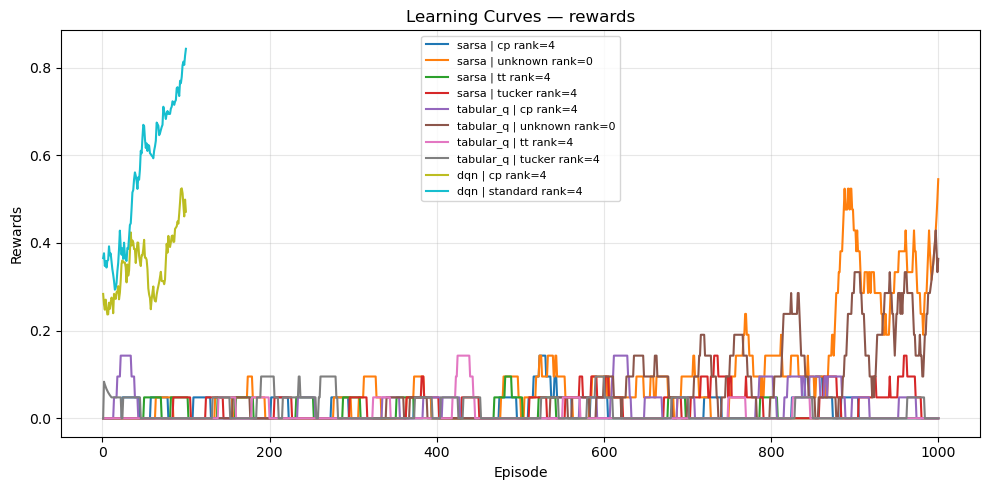

In [10]:
plot_learning_curves(runs, agg_data=agg_runs, metric='rewards', smoothing=20)

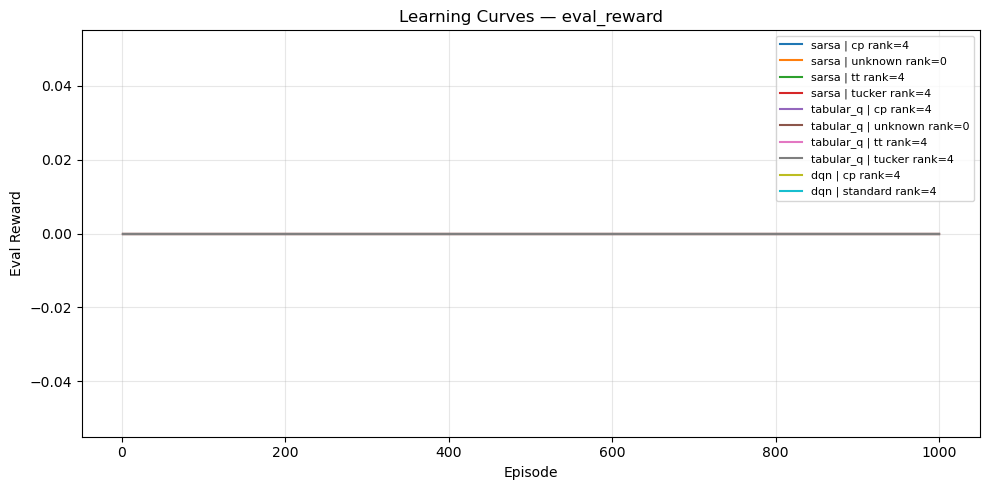

In [11]:
plot_learning_curves(runs, agg_data=agg_runs, metric='eval_reward', smoothing=20)

d:\Skrivebord\OneDrive - Danmarks Tekniske Universitet\Semester 4\02466-Project_Work\tensor_rl\tensor_rl\sim\analysis\stats.py:145: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7, loc="lower right")


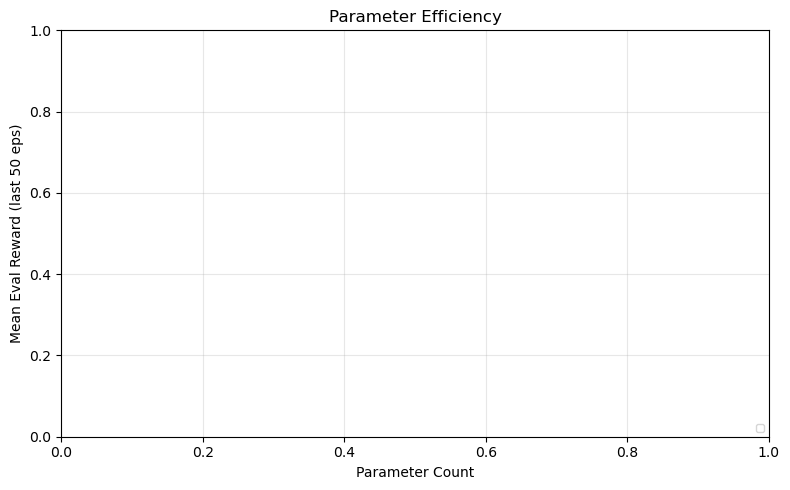

In [12]:
# Each point is one run; structured TN runs should show fewer params with comparable y-axis
plot_param_efficiency(runs)

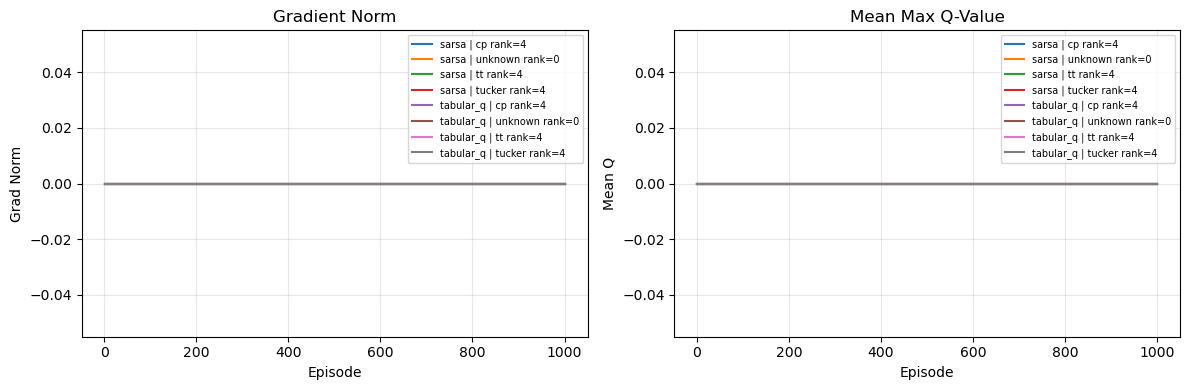

In [13]:
# Gradient norm (left) and mean Q-value magnitude (right)
plot_stability(runs)

In [14]:
if len(runs) >= 2:
    results = run_statistical_tests(runs)
else:
    print('Need at least 2 runs for statistical comparison.')

Network A        Network B            U-stat    p-value   Sig?   Cohen d
------------------------------------------------------------------------
cp               tt                    800.0     1.0000     No     0.000
cp               tucker                800.0     1.0000     No     0.000
cp               unknown               800.0     1.0000     No     0.000
tt               tucker                800.0     1.0000     No     0.000
tt               unknown               800.0     1.0000     No     0.000
tucker           unknown               800.0     1.0000     No     0.000
